# Motor-CAD 새 인스턴스 생성 및 cbh.mot 파일 저장

Motor-CAD의 새로운 인스턴스를 생성하고 cbh.mot 파일로 저장하는 예제입니다.

In [5]:
import ansys.motorcad.core as pymotorcad
import os

# Motor-CAD 새 인스턴스 생성
mcad = pymotorcad.MotorCAD()

In [ ]:
# 기본 모터 파라미터 설정 (선택사항)
# 예: BLDC 모터로 설정
mcad.set_variable("MotorType", 3)  # 3 = BLDC Motor




In [ ]:

# 기본 geometry 파라미터 설정
mcad.set_variable("StatorOuterDiameter", 100)  # mm
mcad.set_variable("StatorInnerDiameter", 60)   # mm
mcad.set_variable("AirGapLength", 0.5)         # mm
mcad.set_variable("MagnetLength", 5)           # mm


# 설정된 파라미터 확인
print("설정된 파라미터:")
print(f"Motor Type: {mcad.get_variable('MotorType')}")
print(f"Stator Outer Diameter: {mcad.get_variable('StatorOuterDiameter')} mm")
print(f"Stator Inner Diameter: {mcad.get_variable('StatorInnerDiameter')} mm")
print(f"Air Gap Length: {mcad.get_variable('AirGapLength')} mm")
print(f"Magnet Length: {mcad.get_variable('MagnetLength')} mm")

# 다시 저장
mcad.save_to_file(file_path)
print(f"\n파라미터 설정 후 '{file_path}'에 다시 저장되었습니다.")

In [ ]:
# 파일 생성 확인
if os.path.exists(file_path):
    file_size = os.path.getsize(file_path)
    print(f"\n✓ cbh.mot 파일이 성공적으로 생성되었습니다.")
    print(f"  파일 경로: {file_path}")
    print(f"  파일 크기: {file_size:,} bytes")
else:
    print("❌ 파일 생성에 실패했습니다.")

# Motor-CAD 인스턴스 닫기 (선택사항)
# 주의: quit() 호출 후에는 mcad 객체를 더 이상 사용할 수 없습니다.
print("\nMotor-CAD 인스턴스를 닫으려면 다음 라인의 주석을 해제하세요:")
print("# mcad.quit()")

# mcad.quit()  # 주석 해제하여 Motor-CAD 인스턴스 닫기

In [1]:
# Copyright (C) 2022 - 2025 ANSYS, Inc. and/or its affiliates.
# SPDX-License-Identifier: MIT
#
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.

"""
.. _ref_BPM_Triangular_Rotor_Notches:

Triangular Rotor Notches for IPM
================================
This script applies the adaptive templates functionality to create triangular rotor notches to
improve NVH performance.
"""
# %%
# .. note::
#    For more information on the use of Adaptive Templates in Motor-CAD, and how to create, modify
#    and debug Adaptive Templates Scripts, see :ref:`ref_adaptive_templates_UG` in the
#    :ref:`ref_user_guide`.
#
# .. note::
#    Adaptive Templates in Motor-CAD require v2024.1.2 (Motor-CAD 2024 R1 Update) or later and
#    PyMotorCAD v0.4.1. To update PyMotorCAD in Motor-CAD, go to Scripting -> Settings -> PyMotorCAD
#    updates and select 'Update to Latest Release'.
#
# This script is designed to be run from Motor-CAD template "e9". If no Motor-CAD file is open, the
# e9 template will be loaded.
#
# This script uses the following adaptive parameters:
#
# * Notch Angle (-4)
#
# * Notch Sweep (5)
#
# * Notch Depth (1)
#
# * Notches per Pole (2)
#
# If these parameters are not already set up in the Motor-CAD file, the parameters will be
# automatically set, with the default values shown in brackets.
#
# To set an adaptive geometry for a Motor-CAD file, a script must be loaded in to the Adaptive
# Templates tab (Geometry -> Editor -> Adaptive Templates) in Motor-CAD and run. When the option
# 'Geometry Templates Type' is set to 'Adaptive', this script is automatically run repeatedly to
# keep the Adaptive Geometry set in Motor-CAD.
#
# .. image:: ../../images/Adaptive_Templates_GUI_Screenshot.png
#
# This Python script can also be executed externally. When executed externally, a Motor-CAD instance
# will be launched and a file based on the "e9" template will be saved to a temporary folder. This
# script will be loaded into the Adaptive Templates tab.

# %%
# Perform Required imports
# ------------------------
# Import the ``pymotorcad`` package to access Motor-CAD. Import the ``triangular_notch`` function to
# create the notch geometry region with Adaptive Templates geometry. Import the ``os``, ``shutil``,
# ``sys``, and ``tempfile`` packages to open and save a temporary MOT file if none is open.

# sphinx_gallery_thumbnail_path = 'images/BPMTriangularRotorNotches.png'
import os
import shutil
import sys
import tempfile

import ansys.motorcad.core as pymotorcad
from ansys.motorcad.core.geometry_shapes import triangular_notch


In [2]:

# %%
# Connect to Motor-CAD
# --------------------
# If this script is loaded into the Adaptive Templates file in Motor-CAD, the current Motor-CAD
# instance is used.
#
# If the script is run externally, these actions occur: a new Motor-CAD instance is opened,
# the e9 IPM motor template is loaded, and the file is saved to a temporary folder.
# To keep a new Motor-CAD instance open after executing the script, use the
# ``MotorCAD(keep_instance_open=True)`` option when opening the new instance.
# Alternatively, use the ``MotorCAD()`` method, which closes the Motor-CAD instance after the
# script is executed.

if pymotorcad.is_running_in_internal_scripting():
    # Use existing Motor-CAD instance if possible
    mc = pymotorcad.MotorCAD(open_new_instance=False)
else:
    mc = pymotorcad.MotorCAD(keep_instance_open=True)
    # Disable popup messages
    mc.set_variable("MessageDisplayState", 2)
    if not "PYMOTORCAD_DOCS_BUILD" in os.environ:
        mc.set_visible(True)
    mc.load_template("e9")


In [3]:

# Open relevant file
working_folder = os.path.join(tempfile.gettempdir(), "adaptive_library")
try:
    shutil.rmtree(working_folder)
except:
    pass
os.mkdir(working_folder)
mot_name = "BPMTriRotorNotches"
mc.save_to_file(working_folder + "/" + mot_name + ".mot")

# Reset geometry to default
mc.reset_adaptive_geometry()


In [6]:
mc.get_variable('CurrentMotFilePath_MotorLAB')

'C:\\Users\\user\\AppData\\Local\\Temp\\adaptive_library/BPMTriRotorNotches.mot'

In [9]:

mc.set_adaptive_parameter_value("Notch Angle", -4)
mc.set_adaptive_parameter_value("Notch Sweep", 5)
mc.set_adaptive_parameter_value("Notch Depth", 1)
mc.set_adaptive_parameter_value("Notches per Pole", 2)



In [10]:

# %%
# Get required parameters and objects
# -----------------------------------
# Get the Adaptive Parameters specified in Motor-CAD, and their values
notch_angle = mc.get_adaptive_parameter_value("notch angle")
notch_angular_width = mc.get_adaptive_parameter_value("notch sweep")
notch_depth = mc.get_adaptive_parameter_value("notch depth")
number_notches = int(mc.get_adaptive_parameter_value("notches per pole"))


In [11]:

# %%
# Get the standard template rotor region from Motor-CAD. Calculate the rotor radius and define the
# rotor centre coordinates.
rotor_region = mc.get_region("Rotor")
rotor_radius = mc.get_variable("RotorDiameter") / 2
duplication_angle = 360 / rotor_region.duplications


In [74]:
notch.entities

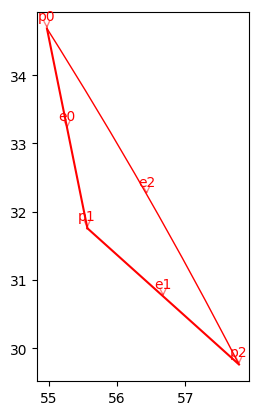

In [73]:
draw_objects_debug(notch)

In [13]:

# %%
# Add an ``if`` statement to account for the case when a notch crosses the symmetry boundary. This
# resets ``notch_angle`` to half the ``notch_angular_width`` away from the boundary.
if notch_angle > (duplication_angle / (2 * number_notches)) - (notch_angular_width / 2):
    # Limit so notch does not cross the symmetry boundary
    notch_angle = (duplication_angle / (2 * number_notches)) - notch_angular_width / 2
    mc.show_message("Adaptive Parameter: 'notch angle' not valid, reset to " + str(notch_angle))
    mc.set_adaptive_parameter_value("notch angle", notch_angle)

# %%
# Add an ``if`` statement to account for the case when notches overlap at the centre of the pole.
# This resets ``notch_angle`` to:
#
# * Half the ``notch_angular_width`` away from the pole centre when there are an even number of
#   notches
#
# * The full ``notch_angular_width`` away from the pole centre when there are an odd number of
#   notches
if number_notches % 2 == 0:
    x = -1
else:
    x = -2

if notch_angle < -((duplication_angle / (2 * number_notches)) - (notch_angular_width / 2)):
    # Limit so notches do not overlap at centre of pole
    notch_angle = x * ((duplication_angle / (2 * number_notches)) - notch_angular_width / 2)
    mc.show_message("Adaptive Parameter: 'notch angle' not valid, reset to " + str(notch_angle))
    mc.set_adaptive_parameter_value("notch angle", notch_angle)

# %%
# Create the Adaptive Templates geometry
# --------------------------------------
# For each notch to be added:
#
# * Calculate the angular position of the notch in mechanical degrees
#
# * Apply the offset angle. For notches on the left side of the pole, the position is shifted by
#   ``+ notch_angle`` mechanical degrees. For notches on the right side of the pole, the position is
#   shifted by ``- notch_angle`` mechanical degrees.
#
# * Create the notch Region using the ``triangular_notch()`` function, imported from
#   ``ansys.motorcad.core.geometry_shapes``. The arguments for the function are:
#
#   * rotor_radius
#
#   * notch_angular_width
#
#   * notch_centre_angle
#
#   * notch_depth
#
# * Define the properties for the notch region
#
#   * name
#
#   * colour
#
#   * duplication angle
#
#   * material
#
# * set the notch's ``parent`` to the rotor region. This will allow Motor-CAD to treat the notch as
#   a sub-region of the rotor and handle subtractions automatically.
#
# * If the notch is closed, set the region in Motor-CAD.

for notch_loop in range(0, number_notches):
    notch_name = "Rotor_Notch_" + str(notch_loop + 1)

    # angular position of notch
    notch_centre_angle = ((2 * notch_loop) + 1) * (duplication_angle / (2 * number_notches))

    # Offset angle by notch_angle
    if notch_centre_angle < duplication_angle / 2:
        notch_centre_angle = notch_centre_angle - notch_angle
    if notch_centre_angle > duplication_angle / 2:
        notch_centre_angle = notch_centre_angle + notch_angle

    # generate a triangular notch region
    notch = triangular_notch(rotor_radius, notch_angular_width, notch_centre_angle, notch_depth)


In [15]:

# notch properties
notch.name = notch_name
notch.colour = (255, 255, 255)
notch.duplications = rotor_region.duplications
notch.material = "Air"
notch.parent = rotor_region

if notch.is_closed():
    mc.set_region(notch)

# %%
# .. image:: ../../images/BPMTriangularRotorNotches.png
#     :width: 300pt

# %%
# Load in Adaptive Templates script if required
# ---------------------------------------------
# When this script is run externally, the script executes the following:
#
# * Set **Geometry type** to **Adaptive**.
#
# * Load the script into the **Adaptive Templates** tab.
#
# * Go to the **Geometry -> Radial** tab to run the Adaptive Templates script and display the new
#   geometry.

# %%
# .. note::
#    When running in a Jupyter Notebook, you must provide the path for the Adaptive Templates script
#    (PY file) instead of ``sys.argv[0]`` when using the ``load_adaptive_script()`` method.
# if not pymotorcad.is_running_in_internal_scripting():
#     mc.set_variable("GeometryTemplateType", 1)
#     mc.load_adaptive_script(sys.argv[0])
#     mc.display_screen("Geometry;Radial")

In [17]:
# Reset geometry to default
mc.reset_adaptive_geometry()

# Use the ``get_region()`` method to get the required regions 
# and store these in the ``standard_regions`` list.
standard_regions = [
    mc. get_region("Rotor Pocket_1"),
    # mc. get_region("Rotor Pocket_2"),
    # mc. get_region("Rotor Pocket_4"),
    # mc. get_region("Rotor Pocket_5"),
    # mc. get_region("RotorDuctFluidRegion_1"),
    # mc. get_region("RotorDuctFluidRegion_2")
]

In [48]:

def get_barrier_centre_and_radius(coordinate_1, coordinate_2, coordinate_3, arc_direction):
    """Calculate barrier arc centre and radius coordinates.

    Parameters
    ----------
    coordinate_1 : Coordinate
        Arc start coordinate.

    coordinate_2 : Coordinate
        Extra coordinate on arc

    coordinate_3 : Coordinate
        Arc end coordinate

    arc_direction : Integer
        Direction to create arc between start/end

    Returns
    -------
    radius : float
        Arc radius

    centre : Coordinate
        Arc centre coordinate
    """
    mcadGeo=pymotorcad.geometry
    _, start_t =mcadGeo.xy_to_rt(coordinate_1.x, coordinate_1.y)
    _, end_t = mcadGeo.xy_to_rt(coordinate_3.x, coordinate_3.y)

    a = (
        coordinate_1.x * (coordinate_2.y - coordinate_3.y)
        - coordinate_1.y * (coordinate_2.x - coordinate_3.x)
        + coordinate_2.x * coordinate_3.y
        - coordinate_3.x * coordinate_2.y
    )
    b = (
        (coordinate_1.x**2 + coordinate_1.y**2) * (coordinate_3.y - coordinate_2.y)
        + (coordinate_2.x**2 + coordinate_2.y**2) * (coordinate_1.y - coordinate_3.y)
        + (coordinate_3.x**2 + coordinate_3.y**2) * (coordinate_2.y - coordinate_1.y)
    )
    c = (
        (coordinate_1.x**2 + coordinate_1.y**2) * (coordinate_2.x - coordinate_3.x)
        + (coordinate_2.x**2 + coordinate_2.y**2) * (coordinate_3.x - coordinate_1.x)
        + (coordinate_3.x**2 + coordinate_3.y**2) * (coordinate_1.x - coordinate_2.x)
    )
    centre = mcadGeo.Coordinate((-b / a) / 2, (-c / a) / 2)
    radius =mcadGeo.Line(centre, coordinate_1).length * arc_direction

    return radius, centre


In [49]:


def get_pockets_include_corner_rounding():
    """Whether corner rounding should be applied to pocket.

    Returns
    -------
        boolean
    """
    return (mc.get_variable("CornerRounding_Rotor") == 1) and (
        mc.get_variable("CornerRoundingRadius_Rotor") > 0
    )



In [ ]:
mcadGeo=pymotorcad.geometry

In [29]:
mcadGeo.Coordinate

ansys.motorcad.core.geometry.Coordinate

In [51]:

def get_rotor_mirror_line():
    """Create mirror line through rotor from origin to airgap.

    Returns
    -------
        Line
    """

    mcadGeo=pymotorcad.geometry
    rotor_radius = mc.get_variable("RotorDiameter")
    number_poles = mc.get_variable("Pole_Number")
    airgap_centre_x, airgap_centre_y = mcadGeo.rt_to_xy(rotor_radius, (360 / number_poles) / 2)

    return mcadGeo.Line(mcadGeo.Coordinate(0, 0), mcadGeo.Coordinate(airgap_centre_x, airgap_centre_y))



In [52]:
line=get_rotor_mirror_line()

In [39]:

def get_coordinates(pocket, coordinate_indices, mirror_line=None):
    """Get list of coordinates from pocket using coordinate_indices.
    Coordinates ordered : start, end, extra coordinate on arc.

    Parameters
    ----------
    pocket : Region
        Pocket region

    coordinate_indices : list of integer
        Pocket region coordinate indices

    mirror_line : Line
        Mirror line to generate extra coordinate on arc

    Returns
    -------
        list of Coordinate
    """
    coordinates = [pocket.points[index] for index in coordinate_indices]
    if mirror_line is not None:
        coordinates.append(coordinates[0].mirror(mirror_line))

    return coordinates


In [53]:


def get_coordinates_no_centre_post(pocket):
    """Get list of coordinates to use to generate top and bottom arcs for pocket.
    Coordinates ordered : start, end, extra coordinate for each arc.

    Returns
    -------
        list of Coordinate
    """
    if get_pockets_include_corner_rounding():
        return get_coordinates(pocket, [2, 8, 5, 11, 17, 14])
    else:
        return get_coordinates(pocket, [1, 5, 3, 6, 0, 8])


In [41]:


def get_coordinates_centre_post(pocket):
    """Get list of coordinates to use to generate top and bottom arcs for pocket.
    Coordinates ordered : start, end, extra coordinate for each arc.

    Parameters
    ----------
    pocket : Region
        Pocket region

    Returns
    -------
        list of Coordinate
    """
    mirror = get_rotor_mirror_line()
    if get_pockets_include_corner_rounding():
        return get_coordinates(pocket, [2, 5], mirror) + get_coordinates(
            pocket, [8, 11], mirror_line=mirror
        )
    else:
        return get_coordinates(pocket, [1, 3], mirror) + get_coordinates(
            pocket, [4, 0], mirror_line=mirror
        )



In [64]:

def update_pocket_geometry(pocket, coordinates):
    """Update the pocket entities to create curved pocket using input coordinates.

    Parameters
    ----------
    pocket : Region
        Pocket region

    coordinates : list of Coordinate
        Coordinates to generate arcs with in region
    """
    entities = []
    # create list of arc entities from coordinates
    for element in range(0, len(coordinates), 3):
        if (element + 1) % 2 == 0:
            # clockwise arc
            arc_direction = -1
        else:
            # ant-clockwise arc
            arc_direction = 1

        # get arc radius and centre point from three coordinates across the arc
        radius, centre = get_barrier_centre_and_radius(
            coordinates[element],  # arc start coordinate
            coordinates[element + 1],  # arc end coordinate
            coordinates[element + 2],  # arc third coordinate
            arc_direction,
        )
        entities.append(
            mcadGeo.Arc(
                coordinates[element],
                coordinates[element + 1],
                centre,
                radius,
            )
        )
    # remove entities between start and end coordinates of each arc then insert into pocket
    for count, element in enumerate(range(0, len(coordinates), 3)):
        start_index = pocket.points.index(coordinates[element])
        end_index = pocket.points.index(coordinates[element + 1])
        if end_index == 0:
            end_index = len(pocket.points)

        # use index of start/end coordinates to remove pockets entities between them
        for index in reversed(range(start_index, end_index)):
            pocket.entities.pop(index)

        pocket.insert_entity(start_index, entities[count])


In [65]:


def get_pocket_name(index):
    """Return unique pocket name used in Motor-CAD.

    Parameters
    ----------
    index : integer
        Current pocket index

    Returns
    -------
        string
    """
    if index == 0:
        return "Rotor Pocket"
    else:
        return "Rotor Pocket_" + str(index)



In [66]:

pocket_number = 0
number_layers = mc.get_variable("Magnet_Layers")


In [57]:

pockets_all_layers = []


In [62]:
outer_thickness = mc.get_array_variable("UShape_Thickness_Outer_Array", 1)
outer_thickness

4

In [67]:

for layer in range(number_layers):
    pockets_single_layer = []

    # get U-Shape layer parameters
    outer_thickness = mc.get_array_variable("UShape_Thickness_Outer_Array", layer)
    outer_post_width = mc.get_array_variable("UShape_Post_Outer_Array", layer)
    inner_thickness = mc.get_array_variable("UShape_Thickness_Inner_Array", layer)
    inner_post_width = mc.get_array_variable("UShape_Post_Inner_Array", layer)
    centre_post_width = mc.get_array_variable("UShape_CentrePost_Array", layer)

    if (inner_thickness == 0) or (outer_thickness == 0):
        message_string = (
            "Unable to create curved barrier for layer "
            + str(layer)
            + ". No inner/outer thickness."
        )
        raise Exception(message_string)
    elif (outer_post_width > 0) or (inner_post_width > 0):
        message_string = (
            "Unable to create curved barrier for layer "
            + str(layer)
            + ". Inner/Outer post width > 0"
        )
        raise Exception(message_string)

    # get pocket from Motor-CAD using unique name
    pocket_left = mc.get_region(get_pocket_name(pocket_number))

    if centre_post_width == 0:
        # no centre post, single rotor pocket in layer
        new_coordinates = get_coordinates_no_centre_post(pocket_left)
    else:
        # centre post, two pockets per layer
        new_coordinates = get_coordinates_centre_post(pocket_left)

    update_pocket_geometry(pocket_left, new_coordinates)
    # increment pocket number to get next pocket from Motor-CAD
    pocket_number += 1

    if pocket_left.is_closed():
        # set region back into Motor-CAD
        mc.set_region(pocket_left)
        # add pocket to layer list for drawing
        pockets_single_layer.append(pocket_left)

    if centre_post_width > 0:
        # mirror left barrier/pocket region across the rotor using mirror line
        pocket_right = pocket_left.mirror(get_rotor_mirror_line(), unique_name=False)
        pocket_right.name = get_pocket_name(pocket_number)
        # increment pocket number to get next pocket from Motor-CAD
        pocket_number += 1

        if pocket_right.is_closed():
            # set region back into Motor-CAD
            mc.set_region(pocket_right)
            # add pocket to layer list for drawing
            pockets_single_layer.append(pocket_left)

    # add pocket regions in this layer to all layers list
    pockets_all_layers = pockets_all_layers + pockets_single_layer


## 

In [78]:
number_notches

2

In [77]:
for notch_loop in range(0, number_notches):
    notch_name = "Rotor_Notch_" + str(notch_loop + 1)

    # angular position of notch
    notch_centre_angle = ((2 * notch_loop) + 1) * (duplication_angle / (2 * number_notches))

    # Offset angle by notch_angle
    if notch_centre_angle < duplication_angle / 2:
        notch_centre_angle = notch_centre_angle - notch_angle
    if notch_centre_angle > duplication_angle / 2:
        notch_centre_angle = notch_centre_angle + notch_angle

    # generate a triangular notch region
    notch = triangular_notch(rotor_radius, notch_angular_width, notch_centre_angle, notch_depth)

    # notch properties
    notch.name = notch_name
    notch.colour = (255, 255, 255)
    notch.duplications = rotor_region.duplications
    notch.material = "Air"
    notch.parent = rotor_region

    if notch.is_closed():
        mc.set_region(notch)

In [ ]:
draw_objects_debug

# draw

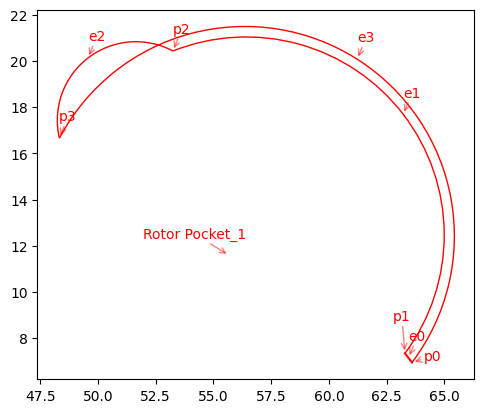

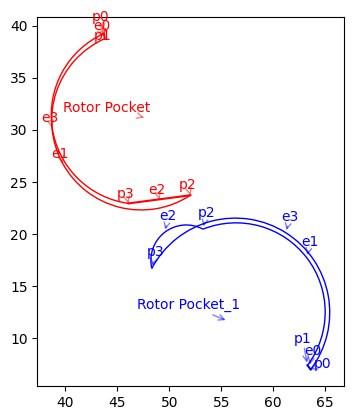

In [79]:
from ansys.motorcad.core.geometry_drawing import draw_objects_debug  

    # draw all pockets in layer
draw_objects_debug(pockets_single_layer)


# draw all regions
draw_objects_debug(pockets_all_layers)

In [75]:
mc.set_region(notch) 


In [ ]:
mc

# Motor-CAD 새 창 열기 및 cbh.mot 파일 저장

새로운 Motor-CAD 인스턴스를 열고 cbh.mot 파일로 저장합니다.

# Maxwell 2D 인스턴스 생성

AEDT Maxwell 2D를 GUI가 보이는 모드로 열어보겠습니다.

In [ ]:
import ansys.aedt.core as pyaedt
from ansys.aedt.core import Maxwell2d

# AEDT 설정
AEDT_VERSION = "2025.1"
NUM_CORES = 8
NG_MODE = False  # GUI를 보이도록 설정

print("Maxwell 2D 인스턴스를 생성합니다...")

# Maxwell 2D 인스턴스 생성 (GUI 보이는 모드)
m2d = Maxwell2d(
    version=AEDT_VERSION,
    new_desktop=True,
    non_graphical=NG_MODE  # False로 설정하여 GUI 표시
)

print(f"✓ Maxwell 2D가 성공적으로 열렸습니다!")
print(f"  Project Name: {m2d.project_name}")
print(f"  Design Name: {m2d.design_name}")
print(f"  AEDT Version: {m2d.aedt_version_id}")
print(f"  GUI Mode: {'Visible' if not NG_MODE else 'Hidden'}")

# Desktop을 visible로 명시적 설정
m2d.desktop_class.visible = True
print("  Desktop GUI가 화면에 표시됩니다.")